In [1]:
# Import packages
import torch
from torchdiffeq import odeint
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import time

In [2]:
# ODE function
def ode_func(t, y, params):
    # Unpack parameters
    mu, theta, eta, k, gamma, gamma_1, gamma_2 = params
    # Unpack state variables
    x, z1, z2 = y
    # ODEs
    dz1 = mu - eta*z1*z2 - gamma_1*z1
    dz2 = theta*x - eta*z1*z2 - gamma_2*z2
    dx = k*z1 - gamma*x
    dy = torch.tensor([dx, dz1, dz2])
    return dy

# Simulation function
def simulate_ode(params, y0, time_points):
    ode_sol = odeint(lambda t, y: ode_func(t, y, params), y0, time_points)
    return ode_sol

# Equilibrium function
def equilibrium_func(y, params):
    return ode_func(0, y, params)

Simulation Time: 3.58


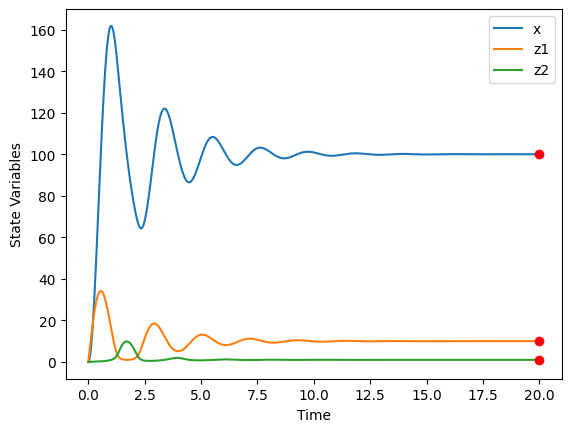

In [9]:
# Simulate the ODE model
y0 = torch.tensor([0, 0, 0]).float().detach()
mu = 100; theta = 1; eta = 10; k = 10; gamma = 1; gamma_1 = 0; gamma_2 = 0
params = torch.tensor([mu, theta, eta, k, gamma, gamma_1, gamma_2]).float().detach()
t = torch.linspace(0, 20, 1000).float().detach()
tic = time.time()
y = simulate_ode(params, y0, t)
toc = time.time()
print('Simulation Time: %.2f' % (toc - tic))

# # Solve the algebraic equations
initial_guess = torch.tensor([1, 1, 1]).float()
equilibrium_solution = fsolve(equilibrium_func, initial_guess, args=(params,))

# Plot the results
plt.plot(t, y)
plt.plot(t[-1], equilibrium_solution[0], 'ro')
plt.plot(t[-1], equilibrium_solution[1], 'ro')
plt.plot(t[-1], equilibrium_solution[2], 'ro')
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.legend(['x', 'z1', 'z2'])
plt.show()